# Dow Data Challenge: Online Bias Learning (OBL)
### CHE 891 — Week 3

The LARS model from Week 2 was trained on Dec 2015–Jan 2017 data.
When applied to the Feb–Oct 2017 validation period, predictions are significantly biased —
a clear sign of process drift.

**OBL** (Qin et al., 2021) corrects this bias online using a Kalman filter update
as new lab measurements arrive.

In [4]:
import joblib
import pandas as pd
import numpy as np
from pylab import *
from sklearn.metrics import r2_score

## 1. Load Data

In [5]:
training_url   = 'http://egr.msu.edu/~scb/courses/EGR891/dow_training_clean.csv'
validation_url = 'http://egr.msu.edu/~scb/courses/EGR891/dow_validation_clean.csv'

df_train = pd.read_csv(training_url,   parse_dates=['Date'])
df_val   = pd.read_csv(validation_url, parse_dates=['Date'])

print(f"Training:   {df_train.shape}")
print(f"Validation: {df_val.shape}")

Training:   (1927, 48)
Validation: (5891, 48)


## 2. Load LARS Model

From Week 2 cross-validation, the optimal number of variables is **A = 10** (best $Q^2$).

In [6]:
feat_cols = [c for c in df_train.columns if c.startswith('x')]

X_train = df_train[feat_cols].values
y_train = df_train['y:Impurity'].values
X_val   = df_val[feat_cols].values
y_val   = df_val['y:Impurity'].values

# define softplus, needed for the model loaded below
def softplus(z):
    return np.logaddexp(z, 0)       # log(1 + exp(z)), numerically stable

def softplus_inv(y):
    return np.log(np.expm1(y))      # log(exp(y) - 1), valid for y > 0


In [8]:
filename = r'C:\Users\Mikey\Desktop\CHE891_Classwork\Process_Design\Class_Jupyter_Files\lars_dow_A10.pkl'
model = joblib.load(filename)
print(f"Model loaded: {model.regressor_['lars'].n_nonzero_coefs} variables")


Model loaded: 28 variables


## 3. The Telltale Sign of Drift

By construction, OLS minimises the sum of squared residuals, so the **mean residual
on the training set is zero**. A large mean residual on the validation set signals
that the process has drifted — the model's baseline is no longer correct.

In [9]:
y_pred_train = model.predict(X_train)
y_pred_val   = model.predict(X_val)

resid_train = y_train - y_pred_train
resid_val   = y_val   - y_pred_val

print(f"Mean residual  — train: {resid_train.mean():+.3f}  (std {resid_train.std():.3f})")
print(f"Mean residual  — val:   {resid_val.mean():+.3f}  (std {resid_val.std():.3f})")
print()
print(f"R²  — train: {r2_score(y_train, y_pred_train):.3f}")
print(f"R²  — val:   {r2_score(y_val,   y_pred_val):.3f}")

Mean residual  — train: +0.021  (std 0.540)
Mean residual  — val:   -0.208  (std 0.666)

R²  — train: 0.772
R²  — val:   0.457


### Plot Residuals over time

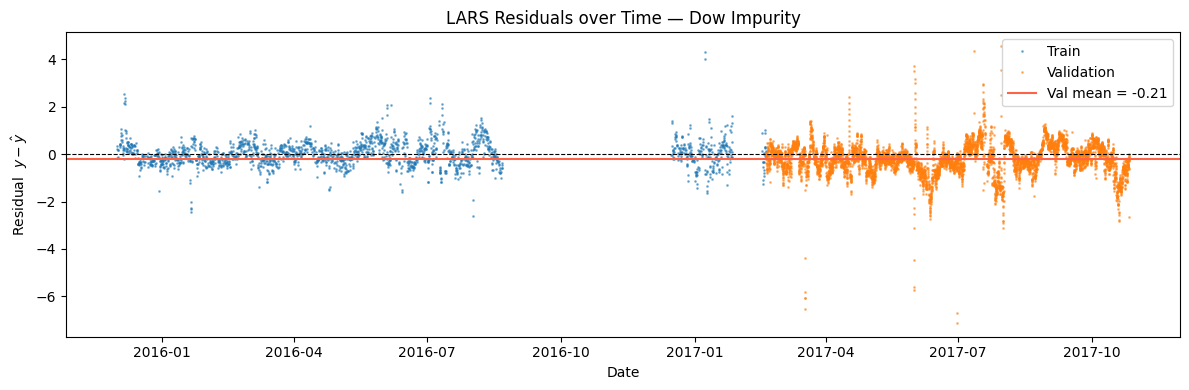

In [10]:
dates_train = df_train['Date'].values
dates_val   = df_val['Date'].values

figure(figsize=(12, 4))
plot(dates_train, resid_train, '.', ms=2, alpha=0.5, label='Train')
plot(dates_val,   resid_val,   '.', ms=2, alpha=0.5, label='Validation')
axhline(0, color='k', lw=0.8, ls='--')
axhline(resid_val.mean(), color='tomato', lw=1.5, ls='-',
        label=f'Val mean = {resid_val.mean():+.2f}')
xlabel('Date')
ylabel(r'Residual  $y - \hat{y}$')
title('LARS Residuals over Time — Dow Impurity')
legend()
tight_layout()
show()

## 4. OBL Function

OBL (Qin et al., 2021, Eq. 7–9) corrects the model prediction $f(\mathbf{x}_t)$ by
adding a time-varying bias estimate $\hat{d}_t$:

$$\hat{y}_t = f(\mathbf{x}_t) + \hat{d}_t$$

The bias is updated after each new lab measurement $y_t$ arrives:

$$\hat{d}_{t+1} = (1 - K)\,\hat{d}_t + K\!\left(y_t - f(\mathbf{x}_t)\right)$$

where $0 < K < 1$ controls the adaptation speed: $K = 1/(n+1)$ for window size $n$.

In [11]:
def obl(model, X, y, K):
    """
    Apply Online Bias Learning to correct model predictions.

    Parameters
    ----------
    model    : fitted TransformedTargetRegressor
    X        : (n_val, n_features) array, time-ordered
    y        : (n_val,) array of true measurements
    K        : OBL hyperparameter 0 < K < 1 controls window size, adaptation speed

    Returns
    -------
    y_pred_obl : bias-corrected predictions
    d          : bias estimate at each step
    """

    if not 0 < K < 1:
        raise ValueError(f"K must be in (0, 1), got {K}")

    n = round(1/K - 1)
    
    y_pred_obl = np.zeros_like(y)
    d = np.zeros(len(y) + 1)   # d[t] is bias applied at step t
    
    for t in range(len(X)):
        y_hat_raw = model.predict(X[t:t+1])[0]
        y_pred_obl[t] = y_hat_raw + d[t]
        d[t+1] = (1 - K) * d[t] + K * (y[t] - y_hat_raw)

    return np.array(y_pred_obl), np.array(d)

## 5. Evaluate OBL

In [12]:
# full datasets:
X = np.vstack([X_train, X_val]) 
y = np.concatenate([y_train, y_val])
dates = np.concatenate([dates_train, dates_val])

In [25]:
K = 0.1   # window ≈ 9 samples; adjust as desired

y_pred_obl, d = obl(model, X, y, K)
n_train = len(y_train)

print("=== Baseline LARS (no correction) ===")
print(f"  Train R²: {r2_score(y_train, model.predict(X_train)):.4f}")
print(f"  Val   R²: {r2_score(y_val,   model.predict(X_val)):.4f}")

print(f"\n=== OBL-corrected  (K = {K}) ===")
print(f"  Train R²: {r2_score(y[:n_train], y_pred_obl[:n_train]):.4f}")
print(f"  Val   R²: {r2_score(y[n_train:], y_pred_obl[n_train:]):.4f}")


=== Baseline LARS (no correction) ===
  Train R²: 0.7721
  Val   R²: 0.4574

=== OBL-corrected  (K = 0.1) ===
  Train R²: 0.8289
  Val   R²: 0.8016


### Rationale for K

In [3]:
# you: write a brief rationale for your choice of K and discuss the above results.

### Plot

In [ ]:
# you: create comparison plots of the OBL result and experimental data comparable
# to Qin Fig. 15. Does not have to be exactly the same!







<div>
    <img src="attachment:86b46615-c570-449f-81a4-db134be27c4b.png", width=400>
</div>

## 6. Sensitivity to K

Best K (max val R²): 0.8913  →  window n ≈ 0
  Train R²: 0.8746
  Val   R²: 0.9170


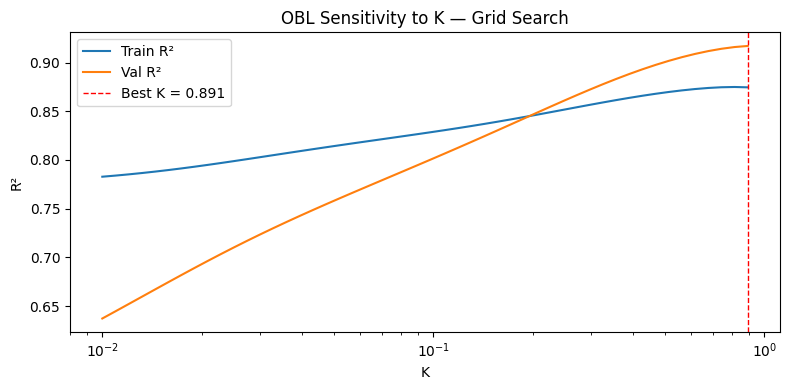

In [26]:
K_values = np.logspace(-2, -0.05, 50)   # 0.01 → ~0.89, log-spaced

n_train = len(y_train)
r2_train_list = []
r2_val_list   = []

for K in K_values:
    y_pred_obl, _ = obl(model, X, y, K)
    r2_train_list.append(r2_score(y[:n_train], y_pred_obl[:n_train]))
    r2_val_list.append(r2_score(y[n_train:],   y_pred_obl[n_train:]))

best_idx = np.argmax(r2_val_list)
best_K   = K_values[best_idx]
print(f"Best K (max val R²): {best_K:.4f}  →  window n ≈ {round(1/best_K - 1)}")
print(f"  Train R²: {r2_train_list[best_idx]:.4f}")
print(f"  Val   R²: {r2_val_list[best_idx]:.4f}")

figure(figsize=(8, 4))
semilogx(K_values, r2_train_list, label='Train R²')
semilogx(K_values, r2_val_list,   label='Val R²')
axvline(best_K, color='r', ls='--', lw=1, label=f'Best K = {best_K:.3f}')
xlabel('K')
ylabel('R²')
title('OBL Sensitivity to K — Grid Search')
legend()
tight_layout()
show()


### Discussion

you: Discuss your findings here.